In [13]:
from pathlib import Path

path = Path("/Users/carlasequero/Desktop/trabajo-fin-master/solution/data/06_training_data/training_01.h5")

print(path.exists())
print(path.stat().st_size / 1024**2, "MB")

True
255.2816619873047 MB


In [14]:
import h5py

path = "/Users/carlasequero/Desktop/trabajo-fin-master/solution/data/06_training_data/training_01.h5"

with h5py.File(path, "r") as f:
    print(list(f.keys()))

['X', 'X_err', 'gaia_source_id', 'gaia_wavelength_nm', 'sdss_obj_id', 'sdss_wavelength_aa', 'y']


In [63]:
with h5py.File(path, "r") as f:
    print("X:", f["X"].shape)
    print("X_err:", f["X_err"].shape)
    print("y:", f["y"].shape)
    print("gaia wavelengths:", f["gaia_wavelength_nm"].shape)
    print("sdss wavelengths:", f["sdss_wavelength_aa"].shape)

X: (15598, 343)
X_err: (15598, 343)
y: (15598, 3600)
gaia wavelengths: (343,)
sdss wavelengths: (3600,)


In [64]:
import numpy as np

with h5py.File(path, "r") as f:
    X = f["X"][:]
    X_err = f["X_err"][:]
    y = f["y"][:]

    gaia_wavelength = f["gaia_wavelength_nm"][:]
    sdss_wavelength = f["sdss_wavelength_aa"][:]

print(X.shape)
print(y.shape)

(15598, 343)
(15598, 3600)


In [65]:
# Nos quedamos solo con el intervalo común de ambos datos 
gaia_mask = (gaia_wavelength >= 450) & (gaia_wavelength <= 900)
sdss_mask = (sdss_wavelength >= 4500) & (sdss_wavelength <= 9000)

X = X[:, gaia_mask]
X_err = X_err[:, gaia_mask]
y = y[:, sdss_mask]

gaia_wavelength = gaia_wavelength[gaia_mask]
sdss_wavelength = sdss_wavelength[sdss_mask]

print(X.shape)
print(y.shape)

(15598, 226)
(15598, 2999)


BORRAR

In [57]:
from scipy.signal import savgol_filter
import numpy as np

def continuum_normalize(flux_matrix, window_length=301, polyorder=3, eps=1e-8):
    n_points = flux_matrix.shape[1]

    if window_length >= n_points:
        window_length = n_points - 1

    if window_length % 2 == 0:
        window_length -= 1

    continuum = savgol_filter(
        flux_matrix,
        window_length=window_length,
        polyorder=polyorder,
        axis=1
    )

    continuum = np.where(np.abs(continuum) < eps, eps, continuum)

    flux_norm = flux_matrix / continuum

    return flux_norm.astype("float32"), continuum.astype("float32")


y_model, y_continuum = continuum_normalize(
    y,
    window_length=301,
    polyorder=3
)

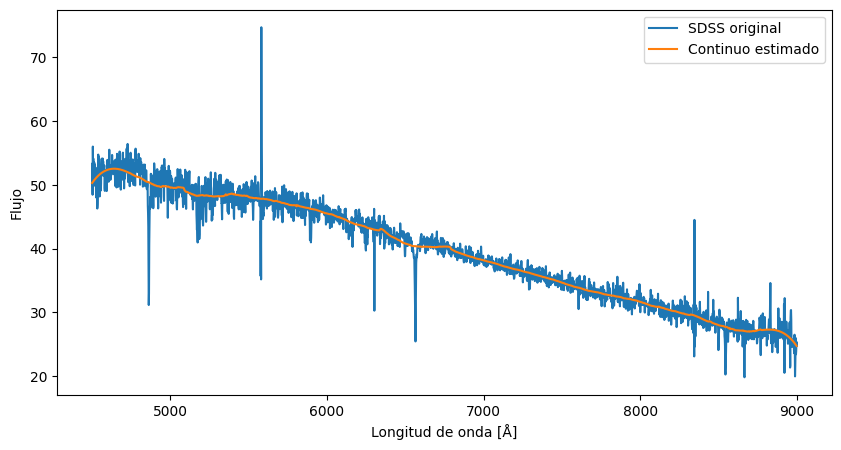

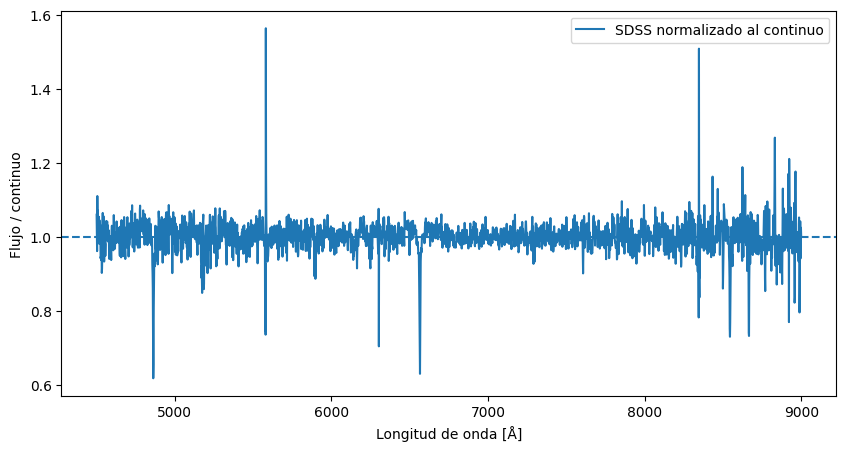

In [58]:
i = 14
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(sdss_wavelength, y[i], label="SDSS original")
plt.plot(sdss_wavelength, y_continuum[i], label="Continuo estimado")
plt.xlabel("Longitud de onda [Å]")
plt.ylabel("Flujo")
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(sdss_wavelength, y_model[i], label="SDSS normalizado al continuo")
plt.axhline(1, linestyle="--")
plt.xlabel("Longitud de onda [Å]")
plt.ylabel("Flujo / continuo")
plt.legend()
plt.show()

In [66]:
low = np.nanpercentile(y, 0.1)
high = np.nanpercentile(y, 99.9)
y_clipped = np.clip(y, low, high)

In [71]:
from sklearn.model_selection import train_test_split

# Separamos en train y temp, luego el temp lo usaremos para separar en test y validation para que los espectros queden mezclados

X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=23,
    shuffle=True
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.2,
    random_state=23,
    shuffle=True
)

# Normalizamos los datos
X_mean = X_train.mean()
X_std = X_train.std()

y_mean = y_train.mean()
y_std = y_train.std()

X_train_norm = (X_train - X_mean) / X_std
X_val_norm = (X_val - X_mean) / X_std
X_test_norm = (X_test - X_mean) / X_std

y_train_norm = (y_train - y_mean) / y_std
y_val_norm = (y_val - y_mean) / y_std
y_test_norm = (y_test - y_mean) / y_std

In [72]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

n_gaia = X_train.shape[1]
n_sdss = y_train.shape[1]

model = models.Sequential([
    layers.Input(shape=(n_gaia,)),

    layers.Dense(512, activation="relu"),

    layers.Dense(1024, activation="relu"),
    
    layers.Dense(1024, activation="relu"),

    layers.Dense(1024, activation="relu"),

    layers.Dense(n_sdss)
])

model.compile(
    optimizer=Adam(learning_rate=1e-4, clipnorm = 1.0),
    loss= tf.keras.losses.Huber(delta=1.0),
    metrics=["mae", "mse"]
)

model.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_60 (Dense)                │ (None, 512)            │       116,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_61 (Dense)                │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_62 (Dense)                │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_63 (Dense)                │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 2999)           │     3,073,975 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,814,711 (22.18 MB)

 Trainable params: 5,814,711 (22.18 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5, # 4 EN SU OPTIMO ESTADO
    restore_best_weights=True
)

from tensorflow.keras.callbacks import ReduceLROnPlateau
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

history = model.fit(
    X_train_norm,
    y_train_norm,
    validation_data=(X_val_norm, y_val_norm),
    epochs=50,
    batch_size=64, #32 PARA QUE VAYA EN SU OPTIMO ESTADO
    callbacks=[early_stop,reduce_lr],
    verbose=1
)


Epoch 1/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 12s 56ms/step - loss: 0.1244 - mae: 0.3155 - mse: 0.8220 - val_loss: 0.0620 - val_mae: 0.1439 - val_mse: 0.4554 - learning_rate: 1.0000e-04
Epoch 2/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 9s 55ms/step - loss: 0.0461 - mae: 0.1223 - mse: 0.3034 - val_loss: 0.0513 - val_mae: 0.1279 - val_mse: 0.2895 - learning_rate: 1.0000e-04
Epoch 3/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 8s 49ms/step - loss: 0.0406 - mae: 0.1117 - mse: 0.2872 - val_loss: 0.0534 - val_mae: 0.1223 - val_mse: 0.3802 - learning_rate: 1.0000e-04
Epoch 4/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 8s 51ms/step - loss: 0.0394 - mae: 0.1121 - mse: 0.2155 - val_loss: 0.0495 - val_mae: 0.1251 - val_mse: 0.2435 - learning_rate: 1.0000e-04
Epoch 5/50
126/156 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - loss: 0.0403 - mae: 0.1073 - mse: 0.2349

In [62]:
y_pred_norm = model.predict(X_test_norm)

y_pred = y_pred_norm * y_std + y_mean
y_test_recalculated = y_test_norm * y_std + y_mean

print("y_test real min/max:", y_test_recalculated.min(), y_test_recalculated.max())
print("y_pred min/max:", y_pred.min(), y_pred.max())

print("y_test percentiles:", np.percentile(y_test_recalculated, [0, 1, 50, 99, 100]))
print("y_pred percentiles:", np.percentile(y_pred, [0, 1, 50, 99, 100]))

98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
y_test real min/max: -36549.81 13026.595
y_pred min/max: -0.37780577 2.4017699
y_test percentiles: [-3.65498086e+04  6.13651741e-01  1.00141585e+00  1.32334682e+00
  1.30265947e+04]
y_pred percentiles: [-0.37780577  0.90945017  0.99957579  1.04840624  2.40176988]


In [46]:
y_pred_norm = model.predict(X_test_norm)
y_pred = y_pred_norm * y_std + y_mean

98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


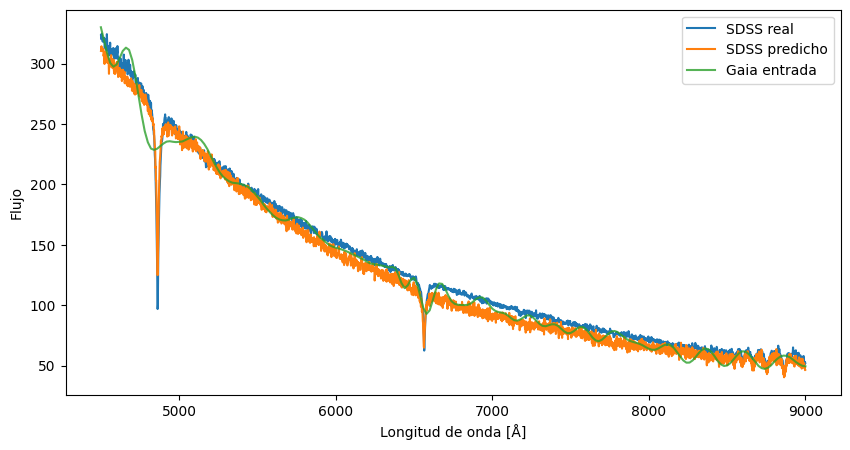

In [47]:
import matplotlib.pyplot as plt

i = 14

gaia_wavelength_ams = gaia_wavelength * 10
gaia_in_sdss_units = X_test[i] / 1e-19

plt.figure(figsize=(10, 5))
plt.plot(sdss_wavelength, y_test[i], label="SDSS real")
plt.plot(sdss_wavelength, y_pred[i], label="SDSS predicho")
plt.plot(gaia_wavelength_ams, gaia_in_sdss_units, label="Gaia entrada", alpha=0.8)
plt.xlabel("Longitud de onda [Å]")
plt.ylabel("Flujo")
plt.legend()
plt.show()

In [70]:
test_loss, test_mae, test_mse = model.evaluate(
    X_test_norm,
    y_test_norm,
    verbose=1
)

98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0410 - mae: 0.0998 - mse: 0.1987


Agrupando por bines

In [ ]:
# Definimos código para agrupar bines de SDSS

def group_bines(wavelength, flux, factor = 2, discard_edges=2):
    n_points_original = flux.shape[1]

    # Definimos la cantidad de puntos a usar como un múltiple del factor (número de bines a agrupar)
    n_points_group = (n_points_original // factor) * factor

    wavelength = wavelength[:n_points_group]
    flux = flux[:, : n_points_group]
    
    grouped_wavelength = wavelength.reshape(-1, factor).mean(axis=1)
    grouped_flux = flux.reshape(flux.shape[0], -1, factor).mean(axis=2)

    # Descartar bordes
    if discard_edges > 0:
        grouped_wavelength = grouped_wavelength[discard_edges:-discard_edges]
        grouped_flux = grouped_flux[:, discard_edges:-discard_edges]

    return grouped_wavelength, grouped_flux


sdss_wavelength_binned, y_binned = group_bines(
    sdss_wavelength,
    y,
    factor=2,
    discard_edges=2
)

print(y_binned.shape)

(15598, 1495)


In [ ]:
from sklearn.model_selection import train_test_split

# Separamos en train y temp, luego el temp lo usaremos para separar en test y validation para que los espectros queden mezclados

X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y_binned,
    test_size=0.2,
    random_state=23,
    shuffle=True
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.2,
    random_state=23,
    shuffle=True
)

# Normalizamos los datos
X_mean = X_train.mean()
X_std = X_train.std()

y_mean = y_train.mean()
y_std = y_train.std()

X_train_norm = (X_train - X_mean) / X_std
X_val_norm = (X_val - X_mean) / X_std
X_test_norm = (X_test - X_mean) / X_std

y_train_norm = (y_train - y_mean) / y_std
y_val_norm = (y_val - y_mean) / y_std
y_test_norm = (y_test - y_mean) / y_std

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

n_gaia = X_train.shape[1]
n_sdss = y_train.shape[1]

model = models.Sequential([
    layers.Input(shape=(n_gaia,)),

    layers.Dense(512, activation="relu"),

    layers.Dense(1024, activation="relu"),

    layers.Dense(1024, activation="relu"),

    layers.Dense(2048, activation="relu"),

    layers.Dense(n_sdss)
])

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="mse", #tf.keras.losses.Huber(delta=1.0),
    metrics=["mae"]
)

model.summary()

In [ ]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

history = model.fit(
    X_train_norm,
    y_train_norm,
    validation_data=(X_val_norm, y_val_norm),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)


In [ ]:
test_loss, test_mae, test_mse = model.evaluate(
    X_test_norm,
    y_test_norm,
    verbose=1
)

In [ ]:
y_pred_norm = model.predict(X_test_norm)
y_pred = y_pred_norm * y_std + y_mean

Probamos un modelo diferente par capas convolucionales

In [ ]:
n_gaia = X_train_norm.shape[1]
n_sdss = y_train_norm.shape[1]

# Para Conv1D necesitamos forma (n_objetos, n_puntos, canales)
X_train_cnn = X_train_norm[..., None]
X_val_cnn = X_val_norm[..., None]
X_test_cnn = X_test_norm[..., None]

model_cnn = models.Sequential([
    layers.Input(shape=(n_gaia, 1)),

    layers.Conv1D(32, kernel_size=7, padding="same", activation="relu"),
    layers.Conv1D(64, kernel_size=7, padding="same", activation="relu"),
    layers.Conv1D(128, kernel_size=5, padding="same", activation="relu"),

    layers.Flatten(),

    layers.Dense(1024, activation="relu"),
    layers.Dense(1024, activation="relu"),
    layers.Dense(512, activation="relu"),

    layers.Dense(n_sdss)
])

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

model_cnn.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss= tf.keras.losses.Huber(delta=1.0),#"mse",
    metrics=["mae", "mse"]
)

model_cnn.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_3 (Conv1D)               │ (None, 226, 32)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 226, 64)        │        14,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 226, 128)       │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 28928)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1024)           │    29,623,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 2999)           │     1,538,487 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,791,927 (125.09 MB)

 Trainable params: 32,791,927 (125.09 MB)

 Non-trainable params: 0 (0.00 B)

In [54]:
history = model_cnn.fit(
    X_train_cnn,
    y_train_norm,
    validation_data=(X_val_cnn, y_val_norm),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 41s 127ms/step - loss: 0.5046 - mae: 0.2879 - mse: 0.5046 - val_loss: 0.4133 - val_mae: 0.1496 - val_mse: 0.4133
Epoch 2/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 45s 143ms/step - loss: 0.2899 - mae: 0.1662 - mse: 0.2899 - val_loss: 0.6909 - val_mae: 0.1634 - val_mse: 0.6909
Epoch 3/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 48s 154ms/step - loss: 0.2777 - mae: 0.1410 - mse: 0.2777 - val_loss: 0.3830 - val_mae: 0.1384 - val_mse: 0.3830
Epoch 4/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 47s 149ms/step - loss: 0.2591 - mae: 0.1275 - mse: 0.2591 - val_loss: 0.2415 - val_mae: 0.1257 - val_mse: 0.2415
Epoch 5/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 47s 150ms/step - loss: 0.1916 - mae: 0.1077 - mse: 0.1916 - val_loss: 0.3413 - val_mae: 0.1278 - val_mse: 0.3413
Epoch 6/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 45s 144ms/step - loss: 0.2492 - mae: 0.1140 - mse: 0.2492 - val_loss: 0.2177 - val_mae: 0.1048 - val_mse: 0.2177
Epoch 7/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 47s 152ms/step - loss: 0.2599 - mae: 0.110

In [56]:
test_loss, test_mae, test_mse = model_cnn.evaluate(
    X_test_cnn,
    y_test_norm,
    verbose=1
)

98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.3110 - mae: 0.1074 - mse: 0.3110


In [58]:
y_pred_norm_cnn = model_cnn.predict(X_test_cnn)
y_pred_cnn = y_pred_norm * y_std + y_mean
y_test_recalculated_cnn = y_test_norm * y_std + y_mean

98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step


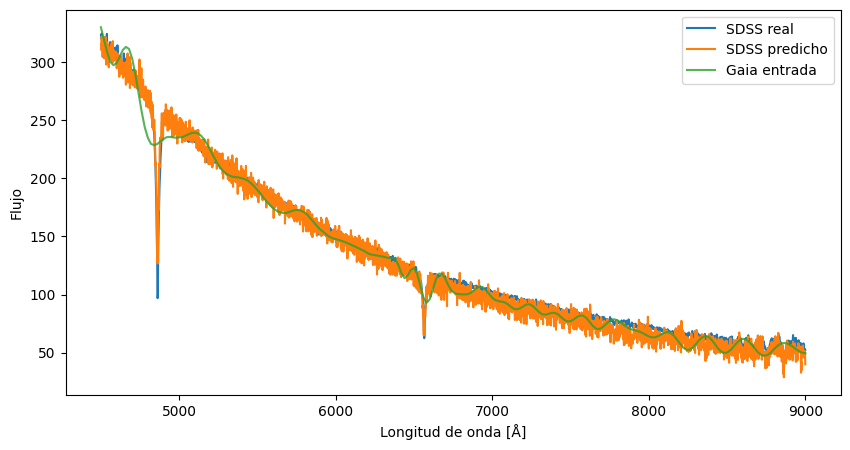

In [59]:
import matplotlib.pyplot as plt

i = 14

gaia_wavelength_ams = gaia_wavelength * 10
gaia_in_sdss_units_cnn = X_test[i] / 1e-19

plt.figure(figsize=(10, 5))
plt.plot(sdss_wavelength, y_test[i], label="SDSS real")
plt.plot(sdss_wavelength, y_pred_cnn[i], label="SDSS predicho")
plt.plot(gaia_wavelength_ams, gaia_in_sdss_units, label="Gaia entrada", alpha=0.8)
plt.xlabel("Longitud de onda [Å]")
plt.ylabel("Flujo")
plt.legend()
plt.show()